In [10]:
import os

# Must be set before any numerical library is imported
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"       # If using Intel MKL
os.environ["NUMEXPR_NUM_THREADS"] = "1"   # If using NumExpr
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  # macOS Accelerate framework

import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal,norm
from collections import defaultdict
import warnings
import sklearn.exceptions
from scipy.special import erfinv
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.notebook import tqdm
import os

from matplotlib.ticker import ScalarFormatter

from types import SimpleNamespace
import matplotlib.pyplot as plt

from _util import *

warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb}'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(edgeitems=30, linewidth=100000, formatter=dict(float=lambda x: "%.3g" % x))


make_plot = lambda n,m,s=[1,1],sharex=False, sharey=False: plt.subplots(n,m,figsize=(m*3*s[0],n*2.5*s[1]),squeeze=False,layout='tight',sharex=sharex, sharey=sharey)


# Define your palettes
color_styles = [
    'k', 'b', 'r', 'g', 'c', 'm', 'y',]

line_styles = [
    '-', '--', '-.', ':'
]

def rank_approx(A, k,sort_type="big_small"):
    # Eigenvalue Decomposition (since A is symmetric, we can use eigh)
    eigenvalues, eigenvectors = np.linalg.eigh(A)
    
    # Sort eigenvalues and corresponding eigenvectors in descending order
    if sort_type == "big_small":
        idx = np.argsort(eigenvalues)[::-1]
    elif sort_type == "small_big":
        idx = np.argsort(eigenvalues)
    
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Select the top-k eigenvalues and eigenvectors
    top_eigenvalues = np.diag(eigenvalues[:k])
    top_eigenvectors = eigenvectors[:, :k]
    
    # Reconstruct the rank-k approximation
    A_k = top_eigenvectors @ top_eigenvalues @ top_eigenvectors.T
    
    return A_k


def print_eig(matrix):

    # Validate symmetry
    if not np.allclose(matrix, matrix.T):
      raise ValueError("Error: The matrix is not symmetric.")
    
    # Compute eigenvalues and eigenvectors using an algorithm optimized for symmetric matrices
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    
    # Sort eigenvalues and corresponding eigenvectors in ascending order.
    sorted_indices = np.argsort(eigenvalues)
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    
    # Create a DataFrame where each column header is a sorted eigenvalue,
    # and the column entries are the corresponding eigenvector components.
    df = pd.DataFrame(sorted_eigenvectors, columns=[f"{val:.4f}" for val in sorted_eigenvalues])
    
    # Append the final row labeled "sum" with the sum of each column (eigenvector)
    df.loc['sum'] = df.sum(axis=0)
    
    # Configure Pandas display options to avoid wrapping the DataFrame after a set number of columns.
    pd.set_option('display.max_columns', None)
    pd.set_option('display.expand_frame_repr', False)
    
    # Print the table to the console.
    print("Eigenvalue Table:")
    print(df)

def compute_metrics(result, C_true, iC_true, Y):

    if result is None or np.isnan(np.sum(result.iC)):
        result_metrics = {
            'err_C': np.nan,
            'err_iC': np.nan,
            'err_S': np.nan,
            'nnz': np.nan,
            'nll': np.nan,
            'sphr': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
            'kl': np.nan,
            'aic':np.nan,
            'runtime': np.nan
        }
        return SimpleNamespace(**result_metrics)

    p, n = Y.shape
    S   = np.cov(Y, bias=True)
    C   = result.C #+ np.eye(p) * 1e-6
    iC  = result.iC #+ np.eye(p) * 1e-6


    # Compute error metrics on covariance/precision matrices
    err_C  = np.linalg.norm(C  - C_true, ord="fro") / np.linalg.norm(C_true, ord="fro")
    err_iC = np.linalg.norm(iC - iC_true, ord="fro") / np.linalg.norm(iC_true, ord="fro")
    err_S  = np.linalg.norm(C  - S, ord="fro")
    nnz    = (np.count_nonzero(iC)-p) / p
    

    log_det_sign, logdet_iC = np.linalg.slogdet(iC)
    if log_det_sign <= 0:
        raise ValueError("Error iC not SPD.")
    nll = -logdet_iC + np.sum(iC * S)  # sum(iC * S) = trace(iC@C)


    sphr   = p * np.sum(iC * iC) / np.trace(iC)**2 - 1  # sum(iC * iC) = trace(iC@iC)
    aic    =  nll + nnz/2 + p

    # Compute KL divergence loss for two zero-mean Gaussians.
    tr_term = float(np.sum(C_true * iC)) # = trace(C_true @ iC )
    log_det_sign, logdet_prod = np.linalg.slogdet(C_true @ iC)  # should be SPD ⇒ s>0
    if log_det_sign <= 0:
        raise ValueError("Error C_true @ iC is not SPD.")
    kl = tr_term - logdet_prod - p

    # Compute F1 score for structure recovery of the precision matrix.
    # Threshold the absolute values to define nonzero connections.
    mask = np.triu(np.ones((p, p), dtype=bool), k=1)

    # --- Binarize supports on masked entries ---
    y_true = (np.abs(iC_true) > 0)[mask]
    y_pred = (np.abs(iC) > 0.0)[mask]

    # --- Counts ---
    tp = int(np.count_nonzero(y_pred &  y_true))
    fp = int(np.count_nonzero(y_pred & ~y_true))
    fn = int(np.count_nonzero(~y_pred &  y_true))
    tn = int(np.count_nonzero(~y_pred & ~y_true))

    # --- Metrics (zero-safe) ---
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    


    # Compile all computed metrics into a structured object.
    result_metrics = {
        'err_C': err_C,
        'err_iC': err_iC,
        'err_S': err_S,
        'nnz': nnz,
        'nll': nll,
        'sphr': sphr,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'kl': kl,
        'aic':aic,
        'runtime': result.runtime
    }
    return SimpleNamespace(**result_metrics)

def metrics_list(results):
    if len(results)<1:
        return []
    if isinstance(results, list) and results:
        # Dynamically retrieve keys from the first result (e.g., 'err_C', 'err_iC', etc.)
        keys = vars(results[0]).keys()
        aggregated = {key: [getattr(r, key) for r in results] for key in keys}
        return SimpleNamespace(**aggregated)
    else:
        return results

# Fig 1

Figure size (width x height in pixels): [7.2 2.5] 0.34722222222222227


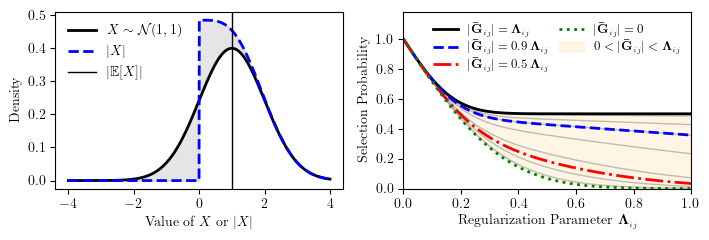

In [11]:
fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)

#########################
#########################
inx = 0
#########################
#########################
mu = 1
sigma = 1
x = np.linspace(-4, 4, 1000)

pdf_normal = sp.stats.norm.pdf(x, mu, sigma)
c = abs(mu / sigma)

pdf_folded  = sp.stats.foldnorm.pdf(x, c, scale=sigma)
mean_folded = sp.stats.foldnorm.mean(c, scale=sigma)

# Normal distribution
axs[0,inx].plot(x, pdf_normal, label=r"$X\sim\mathcal{N}(1,1)$", color="black",linestyle="-",linewidth=2)
axs[0,inx].fill_between(x[x < 0], pdf_normal[x < 0], color='black', alpha=0.1)
axs[0,inx].plot(x, pdf_folded, label=r"$|X|$", color="blue",linestyle="--",linewidth=2)

# Highlighting how negative side maps to positive side in folded normal
axs[0,inx].fill_between(x[x>0],pdf_folded[x > 0], pdf_normal[x > 0], color='black', alpha=0.1)

# Mean lines
axs[0,inx].axvline(mu, color='black', label=r"$|\mathbb{E}[X]|$",linestyle="-",linewidth=1)
#axs[0,inx].axvline(mean_folded, color='blue', label=r"$\mathbb{E}[|X|]$",linestyle="--",linewidth=1)

axs[0, inx].set_xlabel(r'Value of $X$ or $|X|$')
axs[0, inx].set_ylabel(r'Density')
axs[0, inx].legend(loc='upper left',frameon=False,fontsize=10)

#########################
#########################
inx = inx + 1
#########################
#########################
alpha_set = [0.0, 0.2, 0.4, 0.6, 0.8, 0.90, 0.95, 0.99, 1.0]
v = 1.5
k = 20
f = lambda L, alpha: 1 - 0.5 * (
    sp.special.erf((L - alpha * L) / np.sqrt(2 * v / k)) +
    sp.special.erf((L + alpha * L) / np.sqrt(2 * v / k))
)

# Assume axs and inx are already defined
x = np.linspace(0, 1, 1000)

for alpha in alpha_set[1:-1]:
    y = f(x, alpha)
    axs[0, inx].plot(x, y, linestyle='-', linewidth=1, color='gray', alpha=0.5)

axs[0, inx].plot(x, f(x, 1.0), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = \mathbf{\Lambda}_{\scriptscriptstyle{ij}}$",          color="black", linestyle="-", linewidth=2)
axs[0, inx].plot(x, f(x, 0.9), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = 0.9 \, \mathbf{\Lambda}_{\scriptscriptstyle{ij}}$",color="blue", linestyle="--", linewidth=2)
axs[0, inx].plot(x, f(x, 0.5), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = 0.5 \, \mathbf{\Lambda}_{\scriptscriptstyle{ij}}$",      color="red", linestyle="-.", linewidth=2)
axs[0, inx].plot(x, f(x, 0.0), label=r"$|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}| = 0$",color="green", linestyle=":", linewidth=2)
axs[0, inx].fill_between(x, f(x, 0.0), f(x, 1.0),color='orange', alpha=0.1,label=r"$0<|\mathbf{\bar{G}}_{\scriptscriptstyle{ij}}|<\mathbf{\Lambda}_{\scriptscriptstyle{ij}}$")

# axs[0, inx].set_ylabel(r"Probability $\textrm{Pr}[|\bar{\mathbf{G}}_{\scriptscriptstyle{ij}}^{(k)}| > \mathbf{\Lambda}_{\scriptscriptstyle{ij}}]$")
#axs[0, inx].set_ylabel(r"Cumulative Prob. $\textrm{F}(\mathbf{\Lambda}_{\scriptscriptstyle{ij}};\mathbf{\bar{G}}_{\scriptscriptstyle{ij}})$")
axs[0, inx].set_ylabel(r"Selection Probability")
axs[0, inx].set_xlabel(r"Regularization Parameter $\mathbf{\Lambda}_{\scriptscriptstyle{ij}}$")

axs[0, inx].set_ylim([0, 1.18])
axs[0, inx].set_xlim([0, np.max(x)])
axs[0, inx].legend(loc='upper right', frameon=False, fontsize=9, ncol=2,labelspacing=0.3,columnspacing=0.8)


fig.savefig("fig_1.png", dpi=300)

fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

# Fig 2

Gamma is set as is !! 0.01
- gamma: 0.01, c: 30.0, p: 128, n: 2560 n/k: 2.0, nnzpriC: 10.21875  ||iC||: 16.4089606879699 ||C||: 13.605248171539492 
num nnzpr = 10.21875
Gamma is set as is !! 0.1
- gamma: 0.1, c: 30.0, p: 128, n: 2560 n/k: 2.0, nnzpriC: 17.84375  ||iC||: 17.400044507685916 ||C||: 13.93221505564458 
num nnzpr = 17.84375
Gamma is set as is !! 0.2
- gamma: 0.2, c: 30.0, p: 128, n: 2560 n/k: 2.0, nnzpriC: 27.484375  ||iC||: 17.953444115533802 ||C||: 14.092470036255158 
num nnzpr = 27.484375
Gamma is set as is !! 1e-06
- gamma: 1e-06, c: 14.0, p: 32, n: 16 n/k: 2.0, nnzpriC: 1.0  ||iC||: 7.845617566568075 ||C||: 4.990298064170643 
Gamma is set as is !! 0.009778666666666665
- gamma: 0.009778666666666665, c: 14.0, p: 32, n: 16 n/k: 2.0, nnzpriC: 3.5625  ||iC||: 8.061245864312166 ||C||: 5.0339522799156935 
Gamma is set as is !! 0.019556333333333332
- gamma: 0.019556333333333332, c: 14.0, p: 32, n: 16 n/k: 2.0, nnzpriC: 4.9375  ||iC||: 8.377325692113144 ||C||: 5.111485201178961 

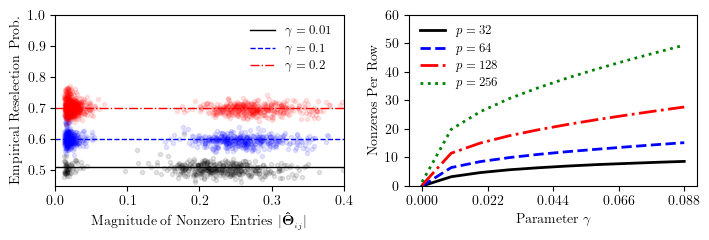

In [12]:
def test1(p=128, N=100, gamma=1/100, data_method='cluster'):

    n = int(p*20)
    k = int(n/2)

    # Precompute covariance and data
    iC_true, C_true = make_cov(p, data_type=data_method, seed=1)
    Y = make_samples(cov=C_true, n=n, seed=1)
    Y, _, _ = normalize_data(Y)
    S = np.cov(Y, bias=True)

    # Aquic result
    res_aquic = compute_aquic(Y, k=k, gamma=gamma, clip_gamma=False)
    iC = res_aquic.iC
    C  = res_aquic.C

    print("num nnzpr =", np.count_nonzero(iC) / p)

    # Precompute threshold matrix L
    diagS = np.diagonal(S)
    V = S**2 + np.outer(diagS, diagS)
    L = sp.special.erfinv(1.0 - 2.0 * gamma) / 2.0 * np.sqrt(2.0 * V / k)
    np.fill_diagonal(L, 1e-12)

    # Vectorized probability matrix P
    P = np.zeros((p, p))
    for i in range(N):
        
        inx_k = np.random.choice(int(n), size=int(k), replace=True)
        #inx_k = np.random.choice(int(n), size=int(k))
        Y_k = Y[:, inx_k]
        #Y_k = make_samples(cov=C_true, n=int(k), seed=i)
        #Y_k, _, _ = normalize_data(Y_k)

        S_k = np.cov(Y_k, bias=True)
        G_k = S_k - C
        np.fill_diagonal(G_k, 0.0)
        P += (np.abs(G_k) >= L)

    P /= N

    mask_nnz  = iC != 0
    mask_triu = np.triu(np.ones((p, p), dtype=bool), k=1)
    pr_nnz = P[mask_nnz & mask_triu].tolist()
    iC_nnz = iC[mask_nnz & mask_triu].tolist()
    pr_z   = P[~mask_nnz & mask_triu].tolist()
    iC_z   = iC[~mask_nnz & mask_triu].tolist()

    return pr_nnz, pr_z, iC_nnz, iC_z

def test2(p=128, n=None, k=None, data_method="cluster", gamma_set=None, N=100, seed=1):
  
    # Storage for results
    nnz_results = np.zeros((N, len(gamma_set)))
    iC_true, C_true = make_cov(p, data_type=data_method, seed=0)
    
    for i in range(N):
        # Generate true covariance and samples for each experiment

        Y = make_samples(cov=C_true, n=int(n), seed=i)

        for j, gamma in enumerate(gamma_set):
            res_aquic = compute_aquic(Y, k=k, gamma=gamma, clip_gamma=False)

            # Count off-diagonal nonzeros per row
            iC = res_aquic.iC.copy()
            np.fill_diagonal(iC, 0)  # Ignore diagonal
            nnz_results[i, j] = np.count_nonzero(iC) / p

    # Compute mean and std across N runs
    nnz_mean = nnz_results.mean(axis=0)
    nnz_std = nnz_results.std(axis=0)

    return nnz_mean, nnz_std


fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)

#########################
#########################
inx = 0
#########################
#########################
p = 128
data_method = "cluster"

for color, linestyle, gamma in [ ('black', '-' , 0.01),('blue' , '--', 0.1),('red',  '-.' , 0.2)]:
    pr_nnz, pr_z, iC_nnz, iC_z = test1(p=p, gamma=gamma, data_method=data_method, N=1000)
    axs[0, inx].plot(iC_nnz,pr_nnz,linestyle='None',marker='.',color=color,alpha=0.1,label="_")
    axs[0, inx].axhline(y=(0.5 + gamma), color=color, linewidth=1, linestyle=linestyle, alpha=1, label=rf'$\gamma={gamma}$')

axs[0, inx].set_ylabel(r'Empirical Reselection Prob.')
axs[0, inx].set_xlabel(r'Magnitude of Nonzero Entries $|\mathbf{\hat{\Theta}}_{\scriptscriptstyle{ij}}|$')

axs[0, inx].set_ylim([0.45,1.0])
axs[0, inx].set_xlim([0.0,0.4])
axs[0, inx].legend(loc='upper right',frameon=False,fontsize=9,ncol=1)


#########################
#########################
inx = inx+1
#########################
#########################

data_method = "cluster"
gamma_min = 1e-6
gamma_max = 0.088  

p = 32
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="black", alpha=1, linestyle='-',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='orange', alpha=0.1,label=r"_")


p = 64
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="blue", alpha=1, linestyle='--',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='orange', alpha=0.1,label=r"_")


p = 128
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="red", alpha=1, linestyle='-.',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='orange', alpha=0.1,label=r"_")


p = 256
n = p/2
k = n/2
gamma_set = np.linspace(gamma_min, gamma_max, 10)
nnz_mean, nnz_std = test2(p=p, n=n, k=k, data_method=data_method, gamma_set=gamma_set, N=100, seed=1)
nnz_min = nnz_mean - nnz_std*2
nnz_max = nnz_mean + nnz_std*2

axs[0, inx].plot(gamma_set, nnz_mean, color="green", alpha=1, linestyle=':',  marker='', linewidth=2, label=rf"$p={p}$")
# axs[0, inx].plot(gamma_set, nnz_min,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label=r"_$\pm \mathrm{{std}}$")
# axs[0, inx].plot(gamma_set, nnz_max,  color="black", alpha=1, linestyle='--', marker='', linewidth=1, label="_")
# axs[0, inx].fill_between(gamma_set, nnz_min, nnz_max, color='orange', alpha=0.1,label=r"_")

axs[0, inx].set_ylabel(r'Nonzeros Per Row')
axs[0, inx].set_xlabel(r'Parameter $\gamma$')

xticks = np.linspace(gamma_set[0], gamma_set[-1], 5)
axs[0, inx].set_xticks(xticks)

axs[0, inx].set_ylim([0,60])

axs[0, inx].legend(loc='upper left',frameon=False,fontsize=9,ncol=1)

fig.savefig("ignore_fig_2.png", dpi=300)

fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

# Fig 3

--> p 64
- gamma: 0.00041011714936722843, c: 10.0, p: 64, n: 32 n/k: 2.0, nnzpriC: 2.15625  ||iC||: 9.748537411747748 ||C||: 8.023300099494517 
- gamma: 0.00041011714936722843, c: 10.0, p: 64, n: 32 n/k: 2.0, nnzpriC: 2.15625  ||iC||: 8.051532542873737 ||C||: 8.017909030491165 
-> 3.65625 6.0015625 8.0625
--> p 128
- gamma: 2.532787780423762e-05, c: 10.0, p: 128, n: 64 n/k: 2.0, nnzpriC: 2.546875  ||iC||: 12.412453882258292 ||C||: 11.260004124428695 
- gamma: 2.532787780423762e-05, c: 10.0, p: 128, n: 64 n/k: 2.0, nnzpriC: 2.546875  ||iC||: 11.454537313877509 ||C||: 11.367140619180478 
-> 4.640625 6.5409375 8.40625
--> p 256
- gamma: 1.763107102759065e-06, c: 10.0, p: 256, n: 128 n/k: 2.0, nnzpriC: 2.7734375  ||iC||: 16.678282450157553 ||C||: 16.19518481840267 
- gamma: 1.763107102759065e-06, c: 10.0, p: 256, n: 128 n/k: 2.0, nnzpriC: 2.7734375  ||iC||: 16.252599313464582 ||C||: 16.089277677461766 
-> 5.5 6.654140625 7.7578125
--> p 512
- gamma: 1.2814848043829485e-07, c: 10.0, p: 512,

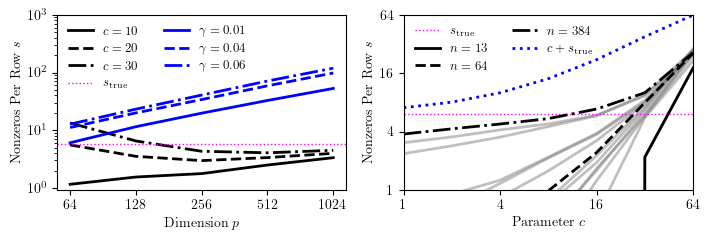

In [13]:
def test_1(iC_true, C_true,n,k,c,seed=0):

    p     = iC_true.shape[0]

    Y      = make_samples(cov=C_true, n=int(n), seed=seed)
    Y,_,_  = normalize_data(Y)
    S      = np.cov(Y,bias=True)

    c_max = (p-1.)/2.
    c     = np.clip(c, 1, c_max-1)
    val   = 1. - c / (2. * (p-c-1.))
    gamma = 0.5 * (1. - sp.special.erf(2. * sp.special.erfinv(val)))
    
    gamma = np.clip(gamma, 1e-16, 0.5 - 1e-16)

    k     = k
    diagS = np.diagonal(S)                         
    V     = S**2 + np.outer(diagS, diagS)              
    L     = sp.special.erfinv(1.0 - 2.0 * gamma) / 2.0 * np.sqrt( 2.0 * V / k)
    np.fill_diagonal(L, 1e-12)

    res_aquic = compute_aquic(Y,c=c,k=k)

    C  = res_aquic.W
    iC = res_aquic.X

    nnzpr_actual = (np.count_nonzero(iC)      - p)/p
    nnzpr_true   = (np.count_nonzero(iC_true) - p)/p

    N = 100
    nnzpr_set = np.zeros(N)

    for i in range(N):
        
        inx_k   = np.random.choice(int(n), size=int(k),replace=False)
        Y_k     = Y[:, inx_k]
        #Y_k,_,_ = normalize_data(Y_k)

        S_k   = np.cov(Y_k, bias=True)
        G_k   = S_k - C
        P     = (np.abs(G_k) >= L) * 1.0
        np.fill_diagonal(P, 1.0)

        nnzpr_set[i] = (np.sum(P) - p)/p
    
    return nnzpr_set,nnzpr_actual,nnzpr_true,gamma

def test_2(c, p_line, data_type,seed=0):
    
    nnz      = np.zeros(len(p_line))
    nnz_true = np.zeros(len(p_line))

    # Metrics for sample-based run (method=1)
    nnz_sample_avg = np.zeros(len(p_line))
    nnz_sample_std = np.zeros(len(p_line))
    
    gamma_set = np.zeros(len(p_line))

    for inx, p in enumerate(p_line):

        print('--> p',p)
        n = int(p / 2)  # Assuming n is half of p
        k = int(n / 2)  # Assuming k is half of n

        # Generate true covariance and data
        iC_true, C_true = make_cov(p, data_type=data_type,seed=inx)
        Y               = make_samples(cov=C_true, n=int(n), seed=inx)

        # Compute AQUIC estimate and metrics
        res_aquic     = compute_aquic(Y, c=c, k=k)
        met_aquic     = compute_metrics(res_aquic, C_true, iC_true, Y)
        s             = (np.count_nonzero(res_aquic.iC) - p) / p
        nnz[inx]      = s
        nnz_true[inx] = (np.count_nonzero(iC_true) - p) / p

        # Sample-based run us n_sampling = 1000 x p 
        n_s = n 
        k_s = k 
        nnzpr_set, nnzpr_actual, nnzpr_true,gamma = test_1(iC_true, C_true, n_s, k_s, c, inx)
        nnz_sample_avg[inx] = np.mean(nnzpr_set)
        nnz_sample_std[inx] = np.std(nnzpr_set)
        gamma_set[inx]      = gamma

        print('->', np.min(nnzpr_set) , np.mean(nnzpr_set),np.max(nnzpr_set))

    return (
        nnz,
        nnz_true,
        nnz_sample_avg,
        nnz_sample_std
    )

def test_3(p, n, k, c_line, data_type,seed=0):
    
    # Generate true covariance and data
    iC_true, C_true = make_cov(p, data_type=data_type,seed=seed)
    Y               = make_samples(cov=C_true, n=int(n), seed=seed)

    nnz             = np.zeros(len(c_line))
    nnz_true        = np.zeros(len(c_line))

    # Metrics for sample-based run (method=1)
    nnz_sample_avg = np.zeros(len(c_line))
    nnz_sample_std = np.zeros(len(c_line))
    
    gamma_set = np.zeros(len(c_line))

    for inx, c in enumerate(c_line):

        print('--> c',c)
        
        # Compute AQUIC estimate and metrics
        res_aquic     = compute_aquic(Y, c=c, k=k)
        met_aquic     = compute_metrics(res_aquic, C_true, iC_true, Y)
        s             = (np.count_nonzero(res_aquic.iC) - p) / p
        nnz[inx]      = s
        nnz_true[inx] = (np.count_nonzero(iC_true) - p) / p

        # Sample-based run us n_sampling = 1000 x p 
        n_s = n 
        k_s = k 
        nnzpr_set, nnzpr_actual, nnzpr_true,gamma = test_1(iC_true, C_true, n_s, k_s, c,inx)
        nnz_sample_avg[inx] = np.mean(nnzpr_set)
        nnz_sample_std[inx] = np.std(nnzpr_set)
        gamma_set[inx] = gamma

        print('->', np.min(nnzpr_set) , np.mean(nnzpr_set),np.max(nnzpr_set))

    return (
        nnz,
        nnz_true,
        nnz_sample_avg,
        nnz_sample_std
    )

def test_4(gamma, p_line, data_type,seed=0):
  
    nnz             = np.zeros(len(p_line))
    nnz_true        = np.zeros(len(p_line))

    # Metrics for sample-based run (method=1)
    nnz_sample_avg = np.zeros(len(p_line))
    nnz_sample_std = np.zeros(len(p_line))
    
    for inx, p in enumerate(p_line):

        print('--> p',p)
        n = int(p / 2)  # Assuming n is half of p
        k = int(n / 2)  # Assuming k is half of n

        # Generate true covariance and data
        iC_true, C_true = make_cov(p, data_type=data_type,seed=inx)
        Y               = make_samples(cov=C_true, n=int(n), seed=inx)

        # Compute AQUIC estimate and metrics
        res_aquic     = compute_aquic(Y, gamma=gamma, k=k, clip_gamma=False)
        met_aquic     = compute_metrics(res_aquic, C_true, iC_true, Y)
        s             = (np.count_nonzero(res_aquic.iC) - p) / p
        nnz[inx]      = s
        nnz_true[inx] = (np.count_nonzero(iC_true) - p) / p

    return (
        nnz,
        nnz_true,
    )

########################################
# Plot
########################################
fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)
data_type   = 'cluster'
line_style  = ['-', '--', '-.', ':']
color_style = ['k', 'b', 'r', 'g']

########################################
inx = 0
########################################
p_line = np.array([64, 128, 256, 512, 1024])


c = 10
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_2(c=c, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="black", alpha=1.0, linestyle='-', marker='', linewidth=2, label=rf"$c={c}$")

c = 20
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_2(c=c, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="black", alpha=1.0, linestyle='--', marker='', linewidth=2, label=rf"$c={c}$")

c = 30
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_2(c=c, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="black", alpha=1.0, linestyle='-.', marker='', linewidth=2, label=rf"$c={c}$")

axs[0,inx].axhline(y=np.mean(nnz_true), color="magenta", alpha=1.0, linestyle=":", linewidth=1, label=r"$s_\text{true}$")

gamma = .01
nnz, nnz_true  = test_4(gamma=gamma, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="blue", alpha=1.0, linestyle='-', marker='', linewidth=2, label=rf"$\gamma={gamma:.2f}$")

gamma = .04
nnz, nnz_true  = test_4(gamma=gamma, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="blue", alpha=1.0, linestyle='--', marker='', linewidth=2, label=rf"$\gamma={gamma:.2f}$")

gamma = .06
nnz, nnz_true  = test_4(gamma=gamma, p_line=p_line, data_type=data_type,seed=0)
axs[0,inx].loglog(p_line,nnz, color="blue", alpha=1.0, linestyle='-.', marker='', linewidth=2, label=rf"$\gamma={gamma:.2f}$")

# y_line = [0,10,20,30,40,50,60]
# axs[0,inx].set_yticks(y_line)
# axs[0,inx].set_yticklabels([str(int(x)) for x in y_line])
axs[0,inx].set_ylim([None,1e3])

# axs[0,inx].minorticks_on()

axs[0,inx].set_xscale("log", base=2)
axs[0,inx].set_xticks(p_line)
axs[0,inx].set_xticklabels([str(int(x)) for x in p_line])

axs[0,inx].set_ylabel(r"Nonzeros Per Row $s$")
axs[0,inx].set_xlabel(r"Dimension $p$")
axs[0,inx].legend(loc='upper left',frameon=False, fontsize=9, ncol=2)


########################################
inx = inx + 1
########################################
p = 128

c_target_line = np.array([1,2,4,8,16,32,64])
iC_true, C_true = make_cov(p, data_type=data_type)
s_true = (np.count_nonzero(iC_true) - p) / p

axs[0, inx].axhline(
    y=s_true,
    color="magenta",
    alpha=1,
    linestyle=":",
    linewidth=1,
    label=r"$s_\text{true}$"
)

r_set = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0]
for i, r in enumerate(r_set):
    n = p * r
    k = n / 2.0
    nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_3(p,n,k,c_target_line, data_type,seed=i)
    nnz_sample_min = nnz_sample_avg - nnz_sample_std*2
    nnz_sample_max = nnz_sample_avg + nnz_sample_std*2

    axs[0,inx].loglog(c_target_line,nnz, color="gray", alpha=.5, linestyle='-',  marker='', linewidth=2 , zorder=1 , label=rf"_")
    print(" - r ", r, "nnz = ",nnz)

r = r_set[0]
n = p * r
k = n / 2.0
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_3(p,n,k,c_target_line, data_type,seed=0)
nnz_sample_min = nnz_sample_avg - nnz_sample_std*2
nnz_sample_max = nnz_sample_avg + nnz_sample_std*2

axs[0,inx].loglog(c_target_line,nnz, color="black", alpha=1, linestyle='-',  marker='', linewidth=2 , label=rf"$n={n:.0f}$")
print("nnz = ",nnz)

r = .5
n = p * r
k = n / 2.0
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_3(p,n,k,c_target_line, data_type,seed=0)
nnz_sample_min = nnz_sample_avg - nnz_sample_std*2
nnz_sample_max = nnz_sample_avg + nnz_sample_std*2
axs[0,inx].loglog(c_target_line,nnz, color="black", alpha=1, linestyle='--',  marker='', linewidth=2 , label=rf"$n={n:.0f}$")
print("nnz = ",nnz)

r = r_set[-1]
n = p * r
k = n / 2.0
nnz, nnz_true, nnz_sample_avg, nnz_sample_std = test_3(p,n,k,c_target_line, data_type,seed=0)
nnz_sample_min = nnz_sample_avg - nnz_sample_std*2
nnz_sample_max = nnz_sample_avg + nnz_sample_std*2
axs[0,inx].loglog(c_target_line,nnz, color="black", alpha=1, linestyle='-.',  marker='', linewidth=2 , label=rf"$n={n:.0f}$")
print("nnz = ",nnz)

#axs[0,inx].loglog(c_target_line,np.clip(c_target_line,s_true,(p-1)/2), color="blue", alpha=1, linestyle=":",  marker='', linewidth=2 , label=r"$\textrm{max}(c,s_\text{true})$")
axs[0,inx].loglog(c_target_line,np.clip(c_target_line + s_true ,None,(p-1)/2), color="blue", alpha=1, linestyle=":",  marker='', linewidth=2 , label=r"$c+s_\text{true}$")

axs[0,inx].set_ylim([np.min(c_target_line),np.max(c_target_line)])
axs[0,inx].set_xlim([np.min(c_target_line),np.max(c_target_line)])
axs[0,inx].set_xticks(c_target_line)
axs[0,inx].set_yticks(c_target_line)
axs[0,inx].set_ylabel(c_target_line)
axs[0,inx].set_xlabel(c_target_line)

axs[0,inx].set_yscale("log", base=2)
axs[0,inx].set_xscale("log", base=2)

# Force tick labels to be plain numbers
y_line = [1,4,16,64]
axs[0,inx].set_yticks(y_line)
axs[0,inx].set_yticklabels([str(int(x)) for x in y_line])
axs[0,inx].set_ylim([min(y_line),max(y_line)])

x_line = [1,4,16,64]
axs[0,inx].set_xticks(x_line)
axs[0,inx].set_xticklabels([str(int(x)) for x in x_line])
axs[0,inx].set_xlim([min(x_line),max(x_line)])

axs[0,inx].set_ylabel(r"Nonzeros Per Row $s$")
axs[0,inx].set_xlabel(r"Parameter $c$")
axs[0,inx].legend(loc='upper left', frameon=False, fontsize=9, ncol=2)
axs[0,inx].minorticks_on()

print('z_max=',(2/3) * (p - 1))
print('s_true=',s_true)
print('nnz ',nnz)

fig.savefig("fig_3.png", dpi=300)

# Fig 4,5 & 5

In [ ]:
def single_run(inx, n, dof, C_true, iC_true):

    p = C_true.shape[0]
    Y = make_samples(cov=C_true, n=int(n), seed=inx,df=dof)
        
    res_glasso = None
    res_tiger  = None
    res_clime  = None
    res_aquic1 = None
    res_aquic2 = None
    res_aquic3 = None

    # GLASSO
    if True: res_glasso = compute_glasso(Y)
    met_glasso = compute_metrics(res_glasso, C_true, iC_true, Y)

    #TIGER 
    if p < 1024:
        if True: res_tiger = compute_tiger(Y)
    met_tiger = compute_metrics(res_tiger, C_true, iC_true, Y)

    # CLIME  
    if p < 512:
        if True: res_clime = compute_clime(Y)
    met_clime = compute_metrics(res_clime, C_true, iC_true, Y)

    k = n/2
    # AQUIC 
    res_aquic1 = compute_aquic(Y,c=60,k=k)
    met_aquic1 = compute_metrics(res_aquic1, C_true, iC_true, Y)

    res_aquic2 = compute_aquic(Y,c=30,k=k)
    met_aquic2 = compute_metrics(res_aquic2, C_true, iC_true, Y)

    res_aquic3 = compute_aquic(Y,c=10,k=k)
    met_aquic3 = compute_metrics(res_aquic3, C_true, iC_true, Y)

    print(
        f"nnzpr:{np.count_nonzero(iC_true)/p:.1f} | "
        f"G[rt:{met_glasso.runtime:.2f}s nnz:{met_glasso.nnz:.0f} f1:{met_glasso.f1:.2f} iC:{met_glasso.err_iC:.2f} C:{met_glasso.err_C:.2f} kl:{met_glasso.kl:.2f}] | "
        f"T[rt:{met_tiger.runtime:.2f}s nnz:{met_tiger.nnz:.0f} f1:{met_tiger.f1:.2f} iC:{met_tiger.err_iC:.2f} C:{met_tiger.err_C:.2f} kl:{met_tiger.kl:.2f}] | "
        f"C[rt:{met_clime.runtime:.2f}s nnz:{met_clime.nnz:.0f} f1:{met_clime.f1:.2f} iC:{met_clime.err_iC:.2f} C:{met_clime.err_C:.2f} kl:{met_clime.kl:.2f}] | "
        f"A1[rt:{met_aquic1.runtime:.2f}s nnz:{met_aquic1.nnz:.0f} f1:{met_aquic1.f1:.2f} iC:{met_aquic1.err_iC:.2f} C:{met_aquic1.err_C:.2f} kl:{met_aquic1.kl:.2f}] | "
        f"A2[rt:{met_aquic2.runtime:.2f}s nnz:{met_aquic2.nnz:.0f} f1:{met_aquic2.f1:.2f} iC:{met_aquic2.err_iC:.2f} C:{met_aquic2.err_C:.2f} kl:{met_aquic2.kl:.2f}] | "
        f"A3[rt:{met_aquic3.runtime:.2f}s nnz:{met_aquic3.nnz:.0f} f1:{met_aquic3.f1:.2f} iC:{met_aquic3.err_iC:.2f} C:{met_aquic3.err_C:.2f} kl:{met_aquic3.kl:.2f}]"
    )
    return {
        'glasso': met_glasso,
        'tiger': met_tiger,
        'clime': met_clime,
        'aquic1': met_aquic1,
        'aquic2': met_aquic2,
        'aquic3': met_aquic3,
        }

def convert_to_dataframes(raw_data):
    out = {}
    # Use the methods in the first task result as reference.
    for method in raw_data[0]:
        # Get the metric names from the first non-None result.
        first_valid = next((ns for ns in raw_data[0][method] if ns is not None), None)
        if first_valid is None:
            continue
        metric_names = list(first_valid.__dict__.keys())
        method_metrics = {}
        # For each metric, build one column per task.
        for metric in metric_names:
            # Each column corresponds to one task (one n_ratio value)
            cols = [
                np.array([ns.__dict__[metric] if ns is not None else np.nan for ns in task[method]])
                for task in raw_data
            ]
            # Stack columns horizontally so that rows are iterations.
            matrix = np.column_stack(cols)
            method_metrics[metric] = pd.DataFrame(matrix, columns=list(range(len(raw_data))))
        out[method] = SimpleNamespace(**method_metrics)
    return out
        
###########################
# FIG 4: Fixed p = 128, change n/p = [1/8, ... 2]/128
###########################
if False:
    p  = 128
    N  = 10

    os.environ["PYTHONWARNINGS"] = "ignore"  # Applies to all subprocesses

    data_type_list = ["cluster", "band", "hub"]

    dataframes = {}
    for data_type in data_type_list:
        print("Processing data type:", data_type)
        
        # Generate covariance matrix and samples.
        iC_true, C_true = make_cov(p, data_type=data_type, seed=0)

        # Define the n_ratio values.
        n_ratio_set = np.logspace(np.log2(1./8.), np.log2(2.0), num=10,base=2)
        
        # For each n_ratio value, run 100 iterations in parallel.
        raw_data = []  # Will be a list (length = number of n_ratio values).
        for n_ratio in n_ratio_set:
            print(f"Running n_ratio={n_ratio} iterations")

            n = int(n_ratio * p)
            dof = np.inf #t distirbtion dof->inf than gaussian

            task_input_list = [(inx, n, dof, C_true, iC_true) for inx in range(N)]
            single_results = []
            for args in tqdm(task_input_list, total=N, desc=f"n_ratio={n_ratio} iterations"):
                result = single_run(*args)
                single_results.append(result)
            
            # For each method, we now want a list of 100 results.
            task_result = {method: [res[method] for res in single_results]
                        for method in single_results[0]}
            raw_data.append(task_result)
        
        # Convert the raw_data (list per n_ratio value) into matrices per metric.
        dataframes[data_type] = convert_to_dataframes(raw_data)

    file_name = 'Nov4_X_NEW_data_err1'+'.pkl'
    pd.to_pickle([n_ratio_set,dataframes], file_name)

###########################
# FIG 5: Fixed n/p = 0.5, change in p = [64,...,2048]
###########################
if True:

    r = 2
    N = 10

    os.environ["PYTHONWARNINGS"] = "ignore" 

    data_type_list = ["cluster", "band", "hub"]

    dataframes = {}
    for data_type in data_type_list:
        print("\n Processing data type:", data_type)
        
        # Define the n_ratio values.
        p_set = [64,128,256,512]

        # For each n_ratio value, run 100 iterations in parallel.
        raw_data = []  # Will be a list (length = number of n_ratio values).
        for p in p_set:
            # Generate covariance matrix and samples.
            iC_true, C_true = make_cov(p, data_type=data_type, seed=0)
            n = 128
            dof = np.inf #t distirbtion dof->inf than gaussian
            task_input_list = [(inx, n, dof, C_true, iC_true) for inx in range(N)]
            single_results = []
            for args in tqdm(task_input_list, total=N, desc=f"p={p} iterations"):
                result = single_run(*args)
                single_results.append(result)
            
            # For each method, we now want a list of 100 results.
            task_result = {method: [res[method] for res in single_results]
                        for method in single_results[0]}
            raw_data.append(task_result)
        
        # Convert the raw_data (list per n_ratio value) into matrices per metric.
        dataframes[data_type] = convert_to_dataframes(raw_data)

    file_name = 'Nov4_X_NEW_data_err2'+'.pkl'
    pd.to_pickle([p_set,dataframes], file_name)

###########################
# FIG 6: Fixed p=128 and n=p/2, change in dof = [2,4,8,16,32]
###########################
if False:

    p  = 128 # n=p/2
    N  = 10

    os.environ["PYTHONWARNINGS"] = "ignore"  # Applies to all subprocesses

    data_type_list = ["cluster", "band", "hub"]

    dataframes = {}
    for data_type in data_type_list:
        print("Processing data type:", data_type)
        
        # Generate covariance matrix and samples.
        iC_true, C_true = make_cov(p, data_type=data_type, seed=0)
        
        # Define the n_ratio values.
        dof_set = [3,4,5,6,10,20]

        # For each n_ratio value, run 100 iterations in parallel.
        raw_data = []  # Will be a list (length = number of n_ratio values).
        for dof in dof_set:
            print(f"Running dof_={dof} iterations")

            n = p/2
            task_input_list = [(inx, n, dof, C_true, iC_true) for inx in range(N)]

            single_results = []
            for args in tqdm(task_input_list, total=N, desc=f"dof_={dof} iterations"):
                result = single_run(*args)
                single_results.append(result)
            
            # For each method, we now want a list of 100 results.
            task_result = {method: [res[method] for res in single_results]
                        for method in single_results[0]}
            raw_data.append(task_result)
        
        # Convert the raw_data (list per n_ratio value) into matrices per metric.
        dataframes[data_type] = convert_to_dataframes(raw_data)

    file_name = 'NEW_data_err3_k1'+'.pkl'
    pd.to_pickle([dof_set,dataframes], file_name)


 Processing data type: cluster


p=64 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
ERROR:tornado.general:SEND Error: Host unreachable
Exception in thread ExecutorManagerThread:
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.9/Frameworks/Python.framework/Versions/3.12/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/opt/homebrew/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py", line 613, in run
    self.join_executor_internals()
  File "/opt/homebrew/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py", line 888, in join_executor_internals
    self.shutdown_workers()
  File "/opt/homebrew/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py

Saving figure...  NEW_data_err1
Figure size (width x height in pixels): [9 12.5] 1.3888888888888888


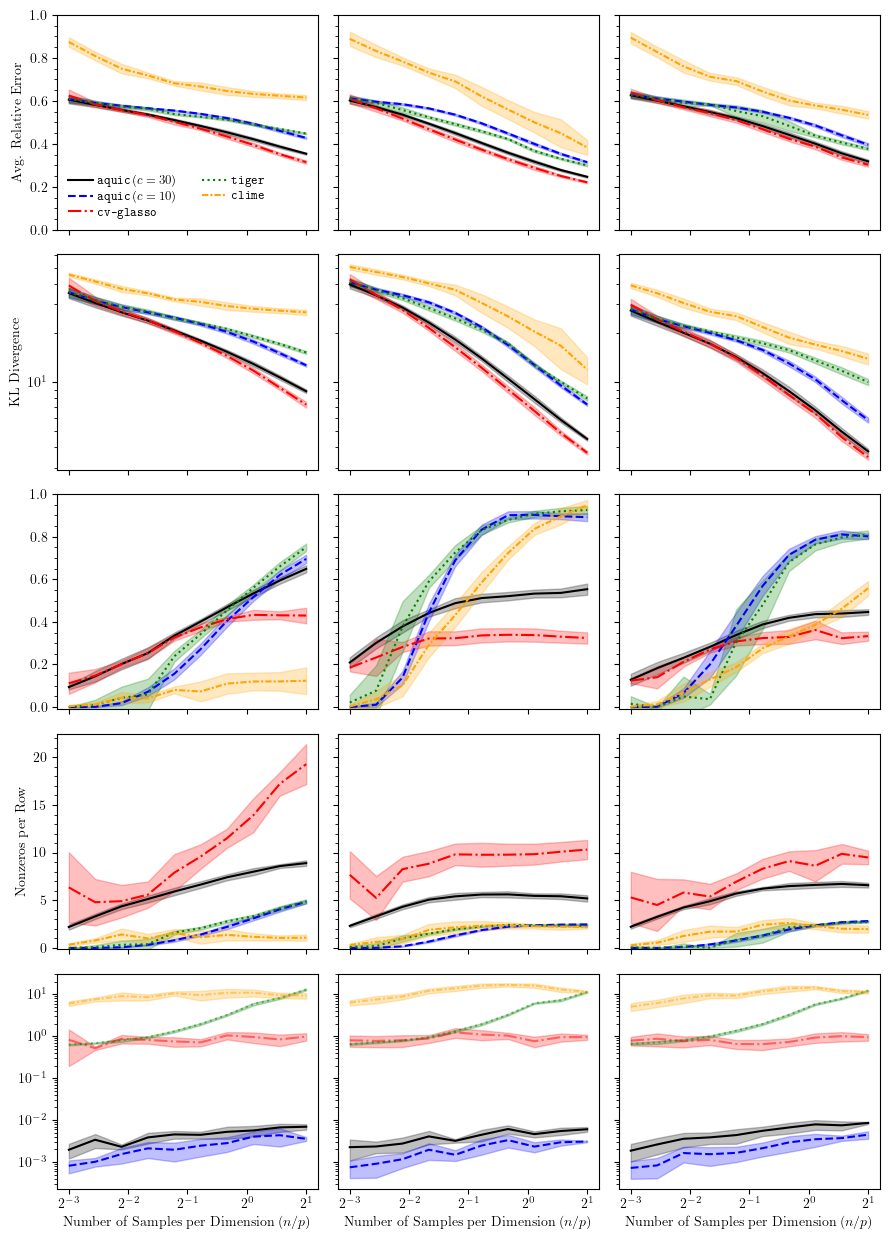

In [24]:
file_name = "NEW_data_err1"
[x_line, dataframe] = pd.read_pickle(file_name + ".pkl") 

line_style = [
    '-',            # solid
    '--',           # dashed
    '-.',           # dash-dot
    ':',                # dotted
    (0, (3, 1, 1, 1)),  # dash-dot-dotted pattern
    (0, (5, 5))     # long dashes
]
line_style = [
    (0, (5, 5)),     # long dashes
    '-',            # solid
    '--',           # dashed
    '-.',           # dash-dot
    ':',                # dotted
    (0, (3, 1, 1, 1)),  # dash-dot-dotted pattern
]

line_alpha = 1.0
fill_alpha = .25

fig, axs = make_plot(5, 3, s=[1, 1], sharex=True, sharey='row')

std_band = 1
i = -1

i = i + 1
# Error in C and iC
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    # m = (dataframe[data_type]['aquic1'].err_iC.mean(0) + dataframe[data_type]['aquic1'].err_C.mean(0)) / 2
    # v = ((dataframe[data_type]['aquic1'].err_iC.std(0) + dataframe[data_type]['aquic1'].err_C.std(0)) / 2) * std_band
    # axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}\, (c=60)$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="black")
    
    # aquic2
    m = (dataframe[data_type]['aquic2'].err_iC.mean(0) + dataframe[data_type]['aquic2'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic2'].err_iC.std(0) + dataframe[data_type]['aquic2'].err_C.std(0)) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic}\, (c=30)$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="black")

    # aquic3
    m = (dataframe[data_type]['aquic3'].err_iC.mean(0) + dataframe[data_type]['aquic3'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic3'].err_iC.std(0) + dataframe[data_type]['aquic3'].err_C.std(0)) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic}\, (c=10)$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="blue")

    # glasso
    m = (dataframe[data_type]['glasso'].err_iC.mean(0) + dataframe[data_type]['glasso'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['glasso'].err_iC.std(0) + dataframe[data_type]['glasso'].err_C.std(0)) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{cv-glasso}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="red")
    
    # tiger
    m = (dataframe[data_type]['tiger'].err_iC.mean(0) + dataframe[data_type]['tiger'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['tiger'].err_iC.std(0) + dataframe[data_type]['tiger'].err_C.std(0)) / 2) * std_band  
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="green")
    
    # clime
    m = (dataframe[data_type]['clime'].err_iC.mean(0) + dataframe[data_type]['clime'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['clime'].err_iC.std(0) + dataframe[data_type]['clime'].err_C.std(0)) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="orange")

axs[i, 0].legend(loc='lower left',frameon=False, 
                 fontsize=9, 
                 ncol=2,
                 #columnspacing=0.5,   # tighten space between columns
                 labelspacing=0.3,    # tighten vertical space between rows
                 handletextpad=0.3    # tighten space between marker/line and label
                )

axs[i, 0].set_ylim([0, 1e0])
axs[i, 0].set_ylabel(r'Avg. Relative Error')
axs[i, 0].minorticks_on()


i = i + 1
# KL Divergence
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    
    # aquic1
    # m = dataframe[data_type]['aquic1'].kl.mean(0)
    # v = dataframe[data_type]['aquic1'].kl.std(0) * std_band
    # axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic} (c=60)$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=line_alpha, color="black")
    
    #aquic2
    m = dataframe[data_type]['aquic2'].kl.mean(0)
    v = dataframe[data_type]['aquic2'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic} (c=30)$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="black")
    
    # aquic3
    m = dataframe[data_type]['aquic3'].kl.mean(0)
    v = dataframe[data_type]['aquic3'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic} (c=10)$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="blue")

    # glasso
    m = dataframe[data_type]['glasso'].kl.mean(0)
    v = dataframe[data_type]['glasso'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{glasso}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].kl.mean(0)
    v = dataframe[data_type]['tiger'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].kl.mean(0)
    v = dataframe[data_type]['clime'].kl.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="orange")

# axs[i, 0].set_ylim([1e0, 1e2])
axs[i, 0].set_ylabel(r'KL Divergence')
# axs[i, 0].minorticks_on()
# #axs[i, 0].legend(loc='upper right', frameon=False, fontsize=10, ncol=2)

i = i + 1
# F1 Score
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    # m = dataframe[data_type]['aquic1'].f1.mean(0)
    # v = dataframe[data_type]['aquic1'].f1.std(0) * std_band
    # axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic} (c=60)$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].f1.mean(0)
    v = dataframe[data_type]['aquic2'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic} (c=30)$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="black")

    # aquic3
    m = dataframe[data_type]['aquic3'].f1.mean(0)
    v = dataframe[data_type]['aquic3'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic} (c=10)$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="blue")
    
    # glasso
    m = dataframe[data_type]['glasso'].f1.mean(0)
    v = dataframe[data_type]['glasso'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{glasso}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="orange")

axs[i, 0].set_ylim([-0.01, 1])
axs[i, 0].set_ylabel(r'')
axs[i, 0].minorticks_on()

i = i + 1
# Nonzeros per Row
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    # m = dataframe[data_type]['aquic1'].nnz.mean(0)
    # v = dataframe[data_type]['aquic1'].nnz.std(0) * std_band
    # axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic} (c=60)$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=line_alpha, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].nnz.mean(0)
    v = dataframe[data_type]['aquic2'].nnz.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic} (c=30)$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="black")
    
    # aquic3
    m = dataframe[data_type]['aquic3'].nnz.mean(0)
    v = dataframe[data_type]['aquic3'].nnz.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic} (c=10)$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="blue")
    
    # glasso
    m = dataframe[data_type]['glasso'].nnz.mean(0)
    v = dataframe[data_type]['glasso'].nnz.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{glasso}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].nnz.mean(0)
    v = dataframe[data_type]['tiger'].nnz.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].nnz.mean(0)
    v = dataframe[data_type]['clime'].nnz.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="orange")

axs[i, 0].set_ylim([-.1, None])
axs[i, 0].set_ylabel(r'Nonzeros per Row')
axs[i, 0].minorticks_on()

i = i + 1
# Runtime
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    # m = dataframe[data_type]['aquic1'].runtime.mean(0)
    # v = dataframe[data_type]['aquic1'].runtime.std(0) * std_band

    # axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic} (c=60)$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=line_alpha, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].runtime.mean(0)
    v = dataframe[data_type]['aquic2'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic} (c=30)$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="black")

    # aquic3
    m = dataframe[data_type]['aquic3'].runtime.mean(0)
    v = dataframe[data_type]['aquic3'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic} (c=10)$", alpha=line_alpha)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="blue")

    # glasso
    m = dataframe[data_type]['glasso'].runtime.mean(0)
    v = dataframe[data_type]['glasso'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{glasso}$", alpha=line_alpha/2)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].runtime.mean(0)
    v = dataframe[data_type]['tiger'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$", alpha=line_alpha/2)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].runtime.mean(0)
    v = dataframe[data_type]['clime'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$", alpha=line_alpha/2)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=fill_alpha, color="orange")
    
    #axs[i, inx].set_xticks([.1,.5,1,1.5, 2])
    axs[i, inx].set_xlabel(r'Number of Samples per Dimension ($n/p$)')

axs[i, 0].set_ylabel(r'')
axs[i, 0].minorticks_on()
axs[i, 0].set_xscale('log', base=2)

# axs[i, 0].set_xticks(x_line)
# axs[i, 0].set_xticklabels([str(int(val)) for val in x_line])

print("Saving figure... ", file_name)
fig.savefig(f"fig_{file_name}.png", dpi=300)
fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

Saving figure to fig_NEW_data_err2.png
Figure size (width x height in pixels): [9 7.5] 0.8333333333333334


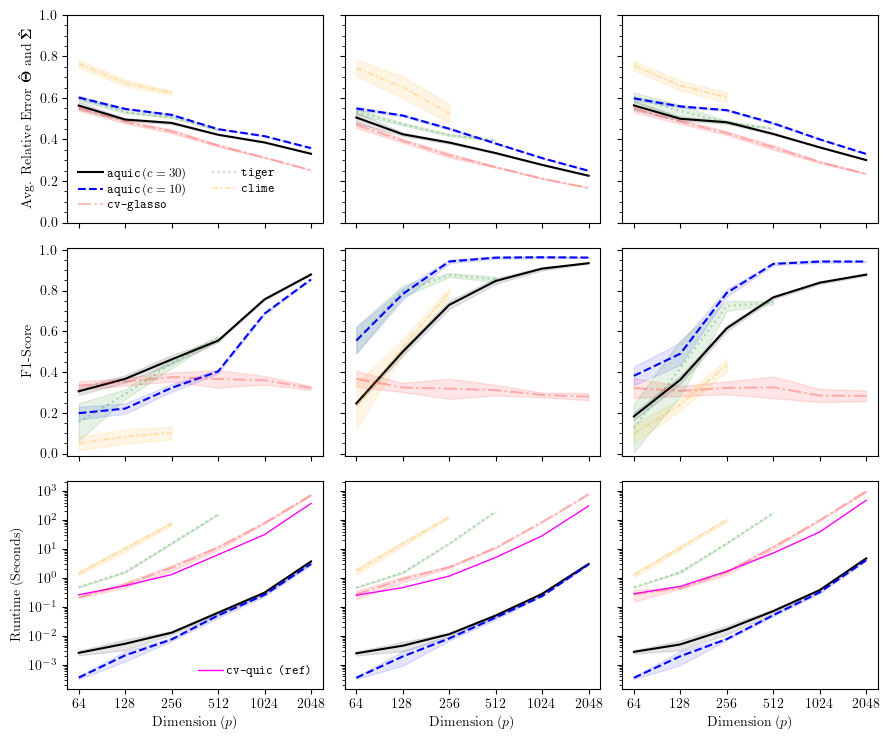

In [9]:
#file_name = "2_data_err2_2"
file_name = "NEW_data_err2"


line_style = [
    '-',            # solid
    '--',           # dashed
    '-.',           # dash-dot
    ':',                # dotted
    (0, (3, 1, 1, 1)),  # dash-dot-dotted pattern
    (0, (5, 5))     # long dashes
]
line_style = [
    (0, (5, 5)),     # long dashes
    '-',            # solid
    '--',           # dashed
    '-.',           # dash-dot
    ':',                # dotted
    (0, (3, 1, 1, 1)),  # dash-dot-dotted pattern
]

[x_line, dataframe] = pd.read_pickle(file_name + ".pkl") 

fig, axs = make_plot(3, 3, s=[1, 1], sharex=True, sharey='row')

std_band = 1
i = -1

i = i + 1
# Error in C and iC
for inx, data_type in enumerate(["cluster", "band", "hub"]):

    err_in_iC = 1
    err_in_C  = 1

    # aquic1
    # m = (dataframe[data_type]['aquic1'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['aquic1'].err_C.mean(0) * err_in_C ) / 2
    # v = ((dataframe[data_type]['aquic1'].err_iC.std(0)*err_in_iC + dataframe[data_type]['aquic1'].err_C.std(0)* err_in_C) / 2) * std_band
    # axs[i, inx].plot(x_line, m, color="magenta", linestyle=line_style[0], label=r"$\texttt{aquic}\,(c=60)$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="magenta")
    
    # aquic2
    m = (dataframe[data_type]['aquic2'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['aquic2'].err_C.mean(0)* err_in_C) / 2
    v = ((dataframe[data_type]['aquic2'].err_iC.std(0)*err_in_iC + dataframe[data_type]['aquic2'].err_C.std(0)* err_in_C) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic}\,(c=30)$",alpha=1.0)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")
    
    # aquic3
    m = (dataframe[data_type]['aquic3'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['aquic3'].err_C.mean(0)* err_in_C) / 2
    v = ((dataframe[data_type]['aquic3'].err_iC.std(0)*err_in_iC + dataframe[data_type]['aquic3'].err_C.std(0)* err_in_C) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic}\,(c=10)$",alpha=1.0)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="blue")

    # glasso
    m = (dataframe[data_type]['glasso'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['glasso'].err_C.mean(0)* err_in_C) / 2
    v = ((dataframe[data_type]['glasso'].err_iC.std(0)*err_in_iC + dataframe[data_type]['glasso'].err_C.std(0)* err_in_C) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{cv-glasso}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="red")
    
    # tiger
    m = (dataframe[data_type]['tiger'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['tiger'].err_C.mean(0)* err_in_C) / 2
    v = ((dataframe[data_type]['tiger'].err_iC.std(0)*err_in_iC + dataframe[data_type]['tiger'].err_C.std(0)* err_in_C) / 2) * std_band  
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="green")
    
    # clime
    m = (dataframe[data_type]['clime'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['clime'].err_C.mean(0)* err_in_C) / 2
    v = ((dataframe[data_type]['clime'].err_iC.std(0)*err_in_iC + dataframe[data_type]['clime'].err_C.std(0)* err_in_C) / 2) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="orange")

axs[i, 0].set_ylim([0, 1.0])
axs[i, 0].set_ylabel(r"Avg. Relative Error $\mathbf{\hat{\Theta}}$ and $\mathbf{\hat{\Sigma}}$")
axs[i, 0].minorticks_on()
axs[i, 0].legend(loc='lower left', 
                 frameon=False, 
                 fontsize=9, 
                 ncol=2,
                 #columnspacing=0.5,   # tighten space between columns
                 labelspacing=0.3,    # tighten vertical space between rows
                 handletextpad=0.3    # tighten space between marker/line and label
                )


# i = i + 1
# # KL Divergence
# for inx, data_type in enumerate(["cluster", "band", "hub"]):
#     # # aquic1
#     # m = dataframe[data_type]['aquic1'].kl.mean(0)
#     # v = dataframe[data_type]['aquic1'].kl.std(0) * std_band
#     # axs[i, inx].semilogy(x_line, m, color="magenta", linestyle=line_style[0], label=r"$\texttt{aquic}\,(c=30)$")
#     # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="magenta")
    
#     # aquic2
#     m = dataframe[data_type]['aquic2'].kl.mean(0)
#     v = dataframe[data_type]['aquic2'].kl.std(0) * std_band
#     axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic}\,(c=20)$",alpha=1.0)
#     axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")

#     # aquic3
#     m = dataframe[data_type]['aquic3'].kl.mean(0)
#     v = dataframe[data_type]['aquic3'].kl.std(0) * std_band
#     axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic}\,(c=10)$",alpha=1.0)
#     axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="blue")

#     # glasso
#     m = dataframe[data_type]['glasso'].kl.mean(0)
#     v = dataframe[data_type]['glasso'].kl.std(0) * std_band
#     axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{glasso}$",alpha=0.25)
#     axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="red")
    
#     # tiger
#     m = dataframe[data_type]['tiger'].kl.mean(0)
#     v = dataframe[data_type]['tiger'].kl.std(0) * std_band
#     axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$",alpha=0.25)
#     axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="green")
    
#     # clime
#     m = dataframe[data_type]['clime'].kl.mean(0)
#     v = dataframe[data_type]['clime'].kl.std(0) * std_band
#     axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$",alpha=0.25)
#     axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="orange")

# axs[i, 0].set_ylim([1e1, 2e2])
# axs[i, 0].set_ylabel(r'KL Divergence')
# axs[i, 0].minorticks_on()

i = i + 1
# F1 Score
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    # m = dataframe[data_type]['aquic1'].f1.mean(0)
    # v = dataframe[data_type]['aquic1'].f1.std(0) * std_band
    # axs[i, inx].plot(x_line, m, color="magenta", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="magenta")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].f1.mean(0)
    v = dataframe[data_type]['aquic2'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic}$",alpha=1.0)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")

    # aquic3
    m = dataframe[data_type]['aquic3'].f1.mean(0)
    v = dataframe[data_type]['aquic3'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic}$",alpha=1.0)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="blue")

    # glasso
    m = dataframe[data_type]['glasso'].f1.mean(0)
    v = dataframe[data_type]['glasso'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{glasso}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="orange")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'F1-Score')
axs[i, 0].minorticks_on()

# i = i + 1
# # Nonzeros per Row
# for inx, data_type in enumerate(["cluster", "band", "hub"]):
#     # aquic1
#     # m = dataframe[data_type]['aquic1'].nnz.mean(0)
#     # v = dataframe[data_type]['aquic1'].nnz.std(0) * std_band
#     # axs[i, inx].plot(x_line, m, color="magenta", linestyle=line_style[0], label=r"$\texttt{aquic}$")
#     # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="magenta")
    
#     # aquic2
#     m = dataframe[data_type]['aquic2'].nnz.mean(0)
#     v = dataframe[data_type]['aquic2'].nnz.std(0) * std_band
#     axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic}$")
#     axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")

#     # aquic3
#     m = dataframe[data_type]['aquic3'].nnz.mean(0)
#     v = dataframe[data_type]['aquic3'].nnz.std(0) * std_band
#     axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic}$")
#     axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="blue")

#     # glasso
#     m = dataframe[data_type]['glasso'].nnz.mean(0)
#     v = dataframe[data_type]['glasso'].nnz.std(0) * std_band
#     axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{glasso}$",alpha=0.25)
#     axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="red")
    
#     # tiger
#     m = dataframe[data_type]['tiger'].nnz.mean(0)
#     v = dataframe[data_type]['tiger'].nnz.std(0) * std_band
#     axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$",alpha=0.25)
#     axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="green")
    
#     # clime
#     m = dataframe[data_type]['clime'].nnz.mean(0)
#     v = dataframe[data_type]['clime'].nnz.std(0) * std_band
#     axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$",alpha=0.25)
#     axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="orange")

# axs[i, 0].set_ylim([-.1, None])
# axs[i, 0].set_ylabel(r'Nonzeros per Row')
# axs[i, 0].minorticks_on()

i = i + 1
# Runtime
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    # m = dataframe[data_type]['aquic1'].runtime.mean(0)
    # v = dataframe[data_type]['aquic1'].runtime.std(0) * std_band
    # axs[i, inx].semilogy(x_line, m, color="magenta", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="magenta")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].runtime.mean(0)
    v = dataframe[data_type]['aquic2'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[1], label=r"_$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")
    
    # ref 
    m = m * ((4 +1) * 4  * 5 + 1) 
    v = v
    axs[i, inx].semilogy(x_line, m, color="magenta", linestyle='-', alpha=1, linewidth=1, label=r"$\texttt{cv-quic (ref)}$")

    # aquic3
    m = dataframe[data_type]['aquic3'].runtime.mean(0)
    v = dataframe[data_type]['aquic3'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"_$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="blue")

    # glasso
    m = dataframe[data_type]['glasso'].runtime.mean(0)
    v = dataframe[data_type]['glasso'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"_$\texttt{glasso}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].runtime.mean(0)
    v = dataframe[data_type]['tiger'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"_$\texttt{tiger}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].runtime.mean(0)
    v = dataframe[data_type]['clime'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[5], label=r"_$\texttt{clime}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="orange")

    
    axs[i, inx].set_xticks(x_line)
    axs[i, inx].set_xlabel(r'Dimension ($p$)')

axs[i, 0].legend(loc='lower right', 
                 frameon=False, 
                 fontsize=9, 
                 ncol=2,
                 #columnspacing=0.5,   # tighten space between columns
                 labelspacing=0.3,    # tighten vertical space between rows
                 handletextpad=0.3    # tighten space between marker/line and label
                )
                
# axs[i, 0].set_ylim([0, 1])
axs[i, 0].set_ylabel(r'Runtime (Seconds)')
axs[i, 0].minorticks_on()
axs[i, 0].set_xscale('log', base=2)

axs[i, 0].set_xticks(x_line)
axs[i, 0].set_xticklabels([str(int(val)) for val in x_line])

fig_name = f"fig_{file_name}.png"
print("Saving figure to", fig_name)
fig.savefig(fig_name, dpi=300)
fig_size_pixels = fig.get_size_inches() 
print("Figure size (width x height in pixels):", fig_size_pixels,fig_size_pixels[1]/fig_size_pixels[0])

In [ ]:
#file_name = "2_data_err2_2"
file_name = "NEW_data_err3_k1"

line_style = [
    '-',            # solid
    '--',           # dashed
    '-.',           # dash-dot
    ':',                # dotted
    (0, (3, 1, 1, 1)),  # dash-dot-dotted pattern
    (0, (5, 5))     # long dashes
]

line_style = [
    (0, (5, 5)),     # long dashes
    '-',            # solid
    '--',           # dashed
    '-.',           # dash-dot
    ':',                # dotted
    (0, (3, 1, 1, 1)),  # dash-dot-dotted pattern
]

[x_line, dataframe] = pd.read_pickle(file_name + ".pkl") 

fig, axs = make_plot(3, 3, s=[1, 1], sharex=True, sharey='row')

std_band = 1
i = -1

i = i + 1
# Error in C and iC
for inx, data_type in enumerate(["cluster", "band", "hub"]):

    err_in_iC = 1
    err_in_C  = 1

    # aquic1
    # m = (dataframe[data_type]['aquic1'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['aquic1'].err_C.mean(0) * err_in_C ) / 2
    # v = ((dataframe[data_type]['aquic1'].err_iC.std(0)*err_in_iC + dataframe[data_type]['aquic1'].err_C.std(0)* err_in_C) / 2) * std_band
    # axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}\,(c=60)$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")
    
    # aquic2
    m = (dataframe[data_type]['aquic2'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['aquic2'].err_C.mean(0)* err_in_C) / 2
    v = ((dataframe[data_type]['aquic2'].err_iC.std(0)*err_in_iC + dataframe[data_type]['aquic2'].err_C.std(0)* err_in_C) / 2) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic}\,(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")

    # aquic3
    m = (dataframe[data_type]['aquic3'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['aquic3'].err_C.mean(0)* err_in_C) / 2
    v = ((dataframe[data_type]['aquic3'].err_iC.std(0)*err_in_iC + dataframe[data_type]['aquic3'].err_C.std(0)* err_in_C) / 2) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic}\,(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="blue")

    # glasso
    m = (dataframe[data_type]['glasso'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['glasso'].err_C.mean(0)* err_in_C) / 2
    v = ((dataframe[data_type]['glasso'].err_iC.std(0)*err_in_iC + dataframe[data_type]['glasso'].err_C.std(0)* err_in_C) / 2) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{cv-glasso}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="red")
    
    # tiger
    m = (dataframe[data_type]['tiger'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['tiger'].err_C.mean(0)* err_in_C) / 2
    v = ((dataframe[data_type]['tiger'].err_iC.std(0)*err_in_iC + dataframe[data_type]['tiger'].err_C.std(0)* err_in_C) / 2) * std_band  
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="green")
    
    # clime
    m = (dataframe[data_type]['clime'].err_iC.mean(0)*err_in_iC + dataframe[data_type]['clime'].err_C.mean(0)* err_in_C) / 2
    v = ((dataframe[data_type]['clime'].err_iC.std(0)*err_in_iC + dataframe[data_type]['clime'].err_C.std(0)* err_in_C) / 2) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="orange")

axs[i, 0].set_ylim([0,1.5])
axs[i, 0].set_ylabel(r"Avg. Relative Error $\mathbf{\hat{\Theta}}$ and $\mathbf{\hat{\Sigma}}$")
# axs[i, 0].minorticks_on()

axs[i, 0].legend(loc='lower left',frameon=False,
                 fontsize=9, 
                 ncol=2,
                 #columnspacing=0.5,   # tighten space between columns
                 labelspacing=0.3,    # tighten vertical space between rows
                 handletextpad=0.3    # tighten space between marker/line and label
                )

i = i + 1
# F1 Score
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    
    # aquic1
    # m = dataframe[data_type]['aquic1'].f1.mean(0)
    # v = dataframe[data_type]['aquic1'].f1.std(0)
    # axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}\,(c=60)$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].f1.mean(0) 
    v = dataframe[data_type]['aquic2'].f1.std(0)
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic}\,(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")

    # aquic3
    m = dataframe[data_type]['aquic3'].f1.mean(0) 
    v = dataframe[data_type]['aquic3'].f1.std(0)
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic}\,(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="blue")

    # glasso
    m = dataframe[data_type]['glasso'].f1.mean(0) 
    v = dataframe[data_type]['glasso'].f1.std(0)
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{cv-glasso}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0)
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0)
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="orange")


axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'F1-Score')
axs[i, 0].minorticks_on()


i = i + 1
# nnx
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    
    # aquic1
    # m = dataframe[data_type]['aquic1'].nnz.mean(0)
    # v = dataframe[data_type]['aquic1'].nnz.std(0)
    # axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}\,(c=60)$")
    # axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].nnz.mean(0) 
    v = dataframe[data_type]['aquic2'].nnz.std(0)
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[1], label=r"$\texttt{aquic}\,(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="black")

    # aquic3
    m = dataframe[data_type]['aquic3'].nnz.mean(0) 
    v = dataframe[data_type]['aquic3'].nnz.std(0)
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{aquic}\,(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="blue")

    # glasso
    m = dataframe[data_type]['glasso'].nnz.mean(0) 
    v = dataframe[data_type]['glasso'].nnz.std(0)
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{cv-glasso}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="red")
    
    # tiger
    m = dataframe[data_type]['tiger'].nnz.mean(0)
    v = dataframe[data_type]['tiger'].nnz.std(0)
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{tiger}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="green")
    
    # clime
    m = dataframe[data_type]['clime'].nnz.mean(0)
    v = dataframe[data_type]['clime'].nnz.std(0)
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[5], label=r"$\texttt{clime}$",alpha=0.25)
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.1, color="orange")
    
    # axs[i, inx].set_xticks(x_line)
    axs[i, inx].set_xlabel(r'Degree of Freedom ($\nu$)')
        
    axs[i, 0].set_xticks(x_line)  # your chosen ticks
    axs[i, 0].get_xaxis().set_major_formatter(ScalarFormatter())
    axs[i, 0].ticklabel_format(style='plain', axis='x')  # force plain numbers

axs[i, 0].set_ylim([-.1, None])
axs[i, 0].set_ylabel(r'Nonzeros per Row')
axs[i, 0].minorticks_on()

# axs[i, 0].set_xticks(x_line)
# axs[i, 0].set_xticklabels([f"{val:.0f}" for val in x_line]) 

fig.savefig(f"fig_{file_name}.png", dpi=300)
fig_size_pixels = fig.get_size_inches() 
print("Figure size (width x height in pixels):", fig_size_pixels,fig_size_pixels[1]/fig_size_pixels[0])

In [ ]:
data_method = "hub"


def single_run( k, n, C_true, iC_true):

    p = C_true.shape[0]
    Y = make_samples(cov=C_true, n=int(n), seed=k)
        
    res_aquic = None


    # AQUIC 
    res_aquic = compute_aquic(Y,c=30,k=k)
    res_aquic = compute_metrics(res_aquic, C_true, iC_true, Y)

    print(
        f"nnzpr:{np.count_nonzero(iC_true)/p:.1f} | "
        f"A[rt:{res_aquic.runtime:.2f}s nnz:{res_aquic.nnz:.0f} f1:{res_aquic.f1:.2f} iC:{res_aquic.err_iC:.2f} C:{res_aquic.err_C:.2f} kl:{res_aquic.kl:.2f}] | "
    )
    return {
        'k': k,
        'f1': res_aquic.f1,
        'err_iC': res_aquic.err_iC,
        'err_C': res_aquic.err_C,
        'kl': res_aquic.kl,
        'nll': res_aquic.nll,
        'nnz': res_aquic.nnz,
        'runtime': res_aquic.runtime
        }

p=1024
n=p/2

res = []

for k in [n,n/2,n/4,n/8,n/16]:

    iC_true, C_true = make_cov(p, data_type=data_method, seed=1)
    a = single_run(int(k), n, C_true, iC_true)
    res.append(a)



In [ ]:
print(res)